# Exploratory Data Analysis (EDA)

This notebook explores the labeled insider threat dataset.

The purpose of EDA is to understand the dataset, identify potential issues, and gain insights before applying preprocessing and machine learning models.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
DATA_PATH = Path("../DATA/processed")

df = pd.read_csv(
    DATA_PATH / "labeled_dataset.csv"
)

In [3]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

Dataset Shape: (4000, 49)

Column Names:
['user', 'total_events', 'total_logons', 'total_logoffs', 'after_hours_events', 'weekend_events', 'unique_pcs_x', 'working_days', 'avg_events_per_day', 'first_login_hour', 'last_logout_hour', 'work_duration_hours', 'total_device_events', 'total_connects', 'total_disconnects', 'after_hours_device_events', 'weekend_device_events', 'total_email_events', 'total_email_sent', 'after_hours_email_count', 'weekend_email_count', 'attachment_email_count', 'average_email_size_kb', 'average_recipient_count', 'total_file_events', 'file_open_count', 'file_copy_count', 'file_write_count', 'file_delete_count', 'files_to_removable_media', 'files_from_removable_media', 'unique_files', 'unique_pcs_y', 'after_hours_file_activity', 'weekend_file_count', 'total_http_events', 'http_visit_count', 'http_download_count', 'http_upload_count', 'after_hours_http_count', 'weekend_http_count', 'unique_urls', 'unique_http_pcs', 'O', 'C', 'E', 'A', 'N', 'label']

Data Types:
use

In [4]:
df.info()

print("\nDuplicate Rows:")
print(df.duplicated().sum())

<class 'pandas.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 49 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   user                        4000 non-null   str    
 1   total_events                4000 non-null   int64  
 2   total_logons                4000 non-null   int64  
 3   total_logoffs               4000 non-null   int64  
 4   after_hours_events          4000 non-null   float64
 5   weekend_events              4000 non-null   float64
 6   unique_pcs_x                4000 non-null   int64  
 7   working_days                4000 non-null   int64  
 8   avg_events_per_day          4000 non-null   float64
 9   first_login_hour            4000 non-null   int64  
 10  last_logout_hour            4000 non-null   int64  
 11  work_duration_hours         4000 non-null   int64  
 12  total_device_events         4000 non-null   float64
 13  total_connects              4000 non-null   

In [5]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
user                          0
total_events                  0
total_logons                  0
total_logoffs                 0
after_hours_events            0
weekend_events                0
unique_pcs_x                  0
working_days                  0
avg_events_per_day            0
first_login_hour              0
last_logout_hour              0
work_duration_hours           0
total_device_events           0
total_connects                0
total_disconnects             0
after_hours_device_events     0
weekend_device_events         0
total_email_events            0
total_email_sent              0
after_hours_email_count       0
weekend_email_count           0
attachment_email_count        0
average_email_size_kb         0
average_recipient_count       0
total_file_events             0
file_open_count               0
file_copy_count               0
file_write_count              0
file_delete_count             0
files_to_removable_media      0
files_from_removable_me

# Statistical Summary of Numerical Features

This section provides descriptive statistics for all numerical features in the dataset.

In [6]:
df.describe()

,total_events,total_logons,total_logoffs,after_hours_events,weekend_events,unique_pcs_x,working_days,avg_events_per_day,first_login_hour,last_logout_hour,...,after_hours_http_count,weekend_http_count,unique_urls,unique_http_pcs,O,C,E,A,N,label
count,4000.000000,4000.00000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,...,4000.000000,4000.000000,4000.000000,4000.0,4000.000000,4000.00000,4000.000000,4000.000000,4000.000000,4000.000000
mean,882.571250,487.23325,395.338000,345.264250,20.054500,38.791000,348.502500,2.527725,6.441000,17.926000,...,1805.781750,579.065000,619.382000,1.0,33.176750,31.12000,28.973500,29.079500,29.556000,0.001250
std,411.251398,245.38082,182.557717,329.481241,72.046594,144.937135,62.842571,1.063629,2.435673,2.118879,...,2300.699227,2521.284742,1572.559794,0.0,10.544895,10.96689,11.134913,11.034905,4.966591,0.035338
min,42.000000,21.00000,21.000000,0.000000,0.000000,1.000000,21.000000,1.994382,0.000000,14.000000,...,0.000000,0.000000,42.000000,1.0,10.000000,10.00000,10.000000,10.000000,12.000000,0.000000
25%,712.000000,356.00000,356.000000,166.000000,0.000000,1.000000,356.000000,2.000000,7.000000,17.000000,...,195.000000,0.000000,165.000000,1.0,24.000000,21.00000,19.000000,19.000000,26.000000,0.000000
50%,712.000000,356.00000,356.000000,356.000000,0.000000,1.000000,356.000000,2.000000,7.000000,18.000000,...,779.000000,0.000000,232.000000,1.0,37.000000,34.00000,27.000000,28.000000,30.000000,0.000000
75%,996.000000,637.00000,395.000000,373.000000,0.000000,19.000000,356.000000,2.800112,8.000000,18.000000,...,2721.250000,0.000000,326.000000,1.0,41.000000,40.00000,39.000000,39.000000,33.000000,0.000000
max,4151.000000,2256.00000,1895.000000,2763.000000,1002.000000,1226.000000,515.000000,9.794749,9.000000,23.000000,...,23406.000000,33060.000000,15610.000000,1.0,50.000000,50.00000,50.000000,50.000000,50.000000,1.000000


In [7]:
# Analyze the Target Variable
print(df["label"].value_counts())

print()

print(df["label"].value_counts(normalize=True) * 100)

label
0    3995
1       5
Name: count, dtype: int64

label
0    99.875
1     0.125
Name: proportion, dtype: float64


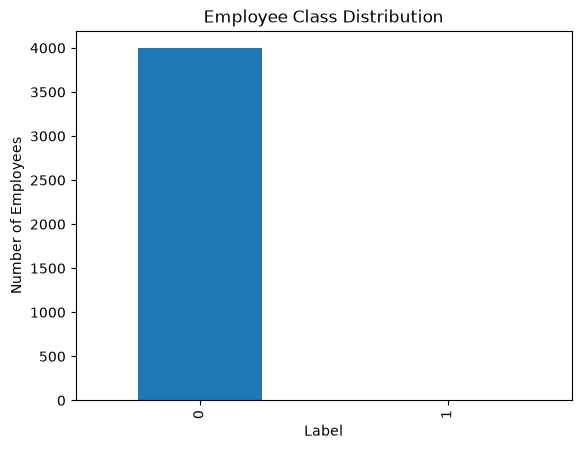

In [8]:
# Visualize Class Distribution
import matplotlib.pyplot as plt

df["label"].value_counts().plot(
    kind="bar"
)

plt.title("Employee Class Distribution")

plt.xlabel("Label")

plt.ylabel("Number of Employees")

plt.show()

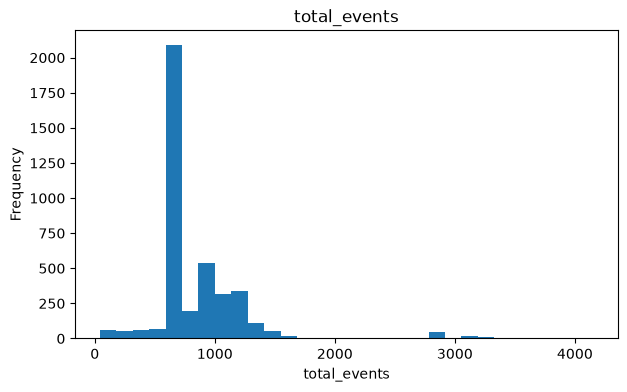

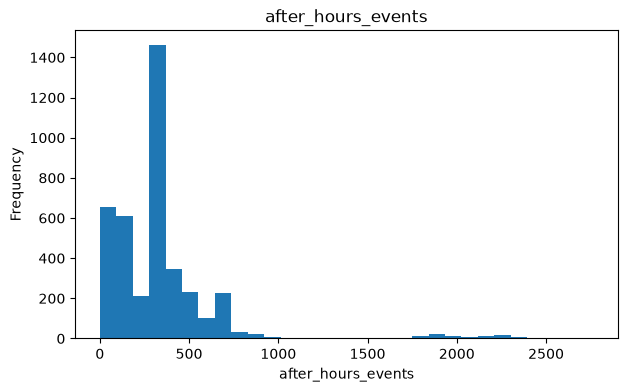

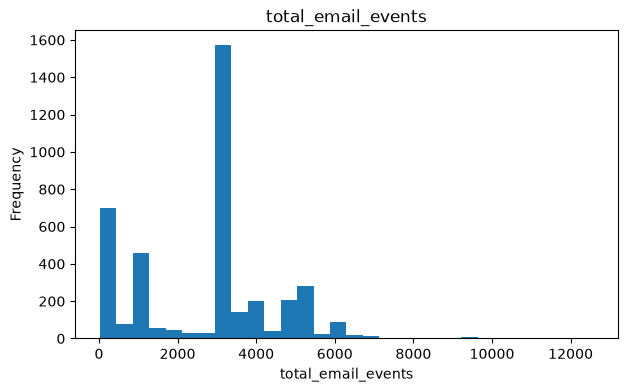

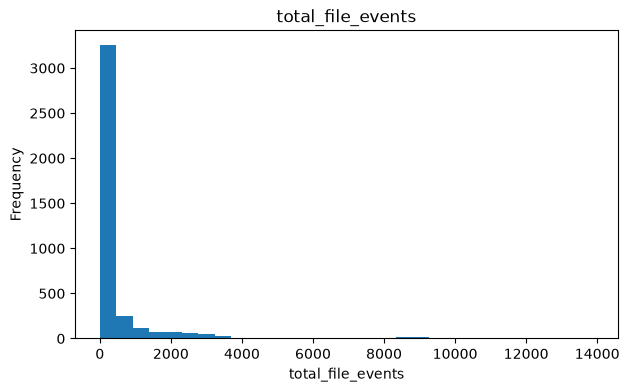

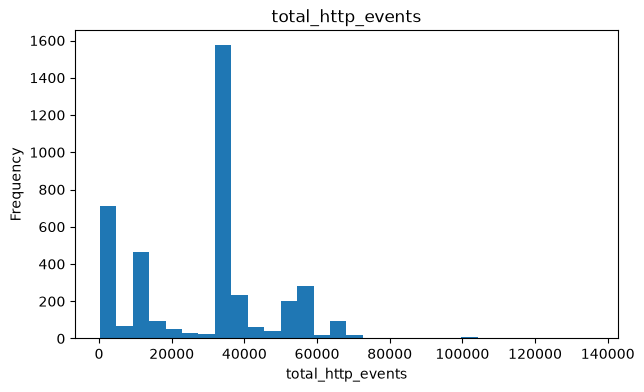

In [9]:
# Feature Distribution Analysis
features = [
    "total_events",
    "after_hours_events",
    "total_email_events",
    "total_file_events",
    "total_http_events"
]

for feature in features:
    plt.figure(figsize=(7,4))

    plt.hist(df[feature], bins=30)

    plt.title(feature)

    plt.xlabel(feature)

    plt.ylabel("Frequency")

    plt.show()

In [10]:
print(df.columns.tolist())

['user', 'total_events', 'total_logons', 'total_logoffs', 'after_hours_events', 'weekend_events', 'unique_pcs_x', 'working_days', 'avg_events_per_day', 'first_login_hour', 'last_logout_hour', 'work_duration_hours', 'total_device_events', 'total_connects', 'total_disconnects', 'after_hours_device_events', 'weekend_device_events', 'total_email_events', 'total_email_sent', 'after_hours_email_count', 'weekend_email_count', 'attachment_email_count', 'average_email_size_kb', 'average_recipient_count', 'total_file_events', 'file_open_count', 'file_copy_count', 'file_write_count', 'file_delete_count', 'files_to_removable_media', 'files_from_removable_media', 'unique_files', 'unique_pcs_y', 'after_hours_file_activity', 'weekend_file_count', 'total_http_events', 'http_visit_count', 'http_download_count', 'http_upload_count', 'after_hours_http_count', 'weekend_http_count', 'unique_urls', 'unique_http_pcs', 'O', 'C', 'E', 'A', 'N', 'label']


# Correlation Analysis

Correlation measures the relationship between numerical features.

Values range from:

- +1 : Strong Positive Correlation
- 0 : No Correlation
- -1 : Strong Negative Correlation

This helps us understand which features move together.

In [11]:
# Correlation Matrix

correlation_matrix = df.corr(numeric_only=True)

correlation_matrix

,total_events,total_logons,total_logoffs,after_hours_events,weekend_events,unique_pcs_x,working_days,avg_events_per_day,first_login_hour,last_logout_hour,...,after_hours_http_count,weekend_http_count,unique_urls,unique_http_pcs,O,C,E,A,N,label
total_events,1.000000,0.971192,0.947315,0.735380,0.339819,0.860470,0.426199,0.899965,-0.505476,0.455435,...,0.051068,0.232800,0.142911,NaN,0.016973,0.024749,0.015544,-0.011018,0.012002,0.002721
total_logons,0.971192,1.000000,0.843696,0.634220,0.374816,0.749708,0.414602,0.871617,-0.477398,0.427605,...,0.065634,0.257647,0.176076,NaN,0.009595,0.031739,0.016173,-0.008197,0.012940,0.006772
total_logoffs,0.947315,0.843696,1.000000,0.804132,0.261717,0.930695,0.402829,0.855805,-0.497011,0.451212,...,0.026822,0.178123,0.085270,NaN,0.025337,0.013092,0.013279,-0.013804,0.009644,-0.002973
after_hours_events,0.735380,0.634220,0.804132,1.000000,0.131874,0.800822,0.187988,0.719835,-0.473050,0.505000,...,0.288462,0.075989,0.052245,NaN,0.013967,0.014631,0.001062,-0.007848,0.001541,-0.003465
weekend_events,0.339819,0.374816,0.261717,0.131874,1.000000,0.096607,0.435966,0.151382,-0.207656,0.180124,...,0.131044,0.807528,0.176808,NaN,-0.020641,0.007091,0.022470,-0.002739,0.014117,-0.009652
unique_pcs_x,0.860470,0.749708,0.930695,0.800822,0.096607,1.000000,0.049152,0.918941,-0.447479,0.404311,...,-0.046642,0.036096,0.037220,NaN,0.028410,0.012419,0.004910,-0.007435,0.013225,0.015089
working_days,0.426199,0.414602,0.402829,0.187988,0.435966,0.049152,1.000000,0.024731,-0.094893,0.096856,...,0.178180,0.374393,0.119153,NaN,-0.003057,0.004330,0.025135,-0.022267,-0.003978,-0.042960
avg_events_per_day,0.899965,0.871617,0.855805,0.719835,0.151382,0.918941,0.024731,1.000000,-0.523768,0.466102,...,-0.023659,0.077522,0.102169,NaN,0.018892,0.024013,0.009345,-0.001526,0.012842,0.045365
first_login_hour,-0.505476,-0.477398,-0.497011,-0.473050,-0.207656,-0.447479,-0.094893,-0.523768,1.000000,-0.763502,...,-0.107379,-0.141011,-0.153789,NaN,-0.025263,-0.024637,0.009854,-0.016563,0.005462,-0.020933
last_logout_hour,0.455435,0.427605,0.451212,0.505000,0.180124,0.404311,0.096856,0.466102,-0.763502,1.000000,...,0.171381,0.124859,0.127329,NaN,0.005823,0.019074,-0.006718,0.027427,0.000845,0.014594


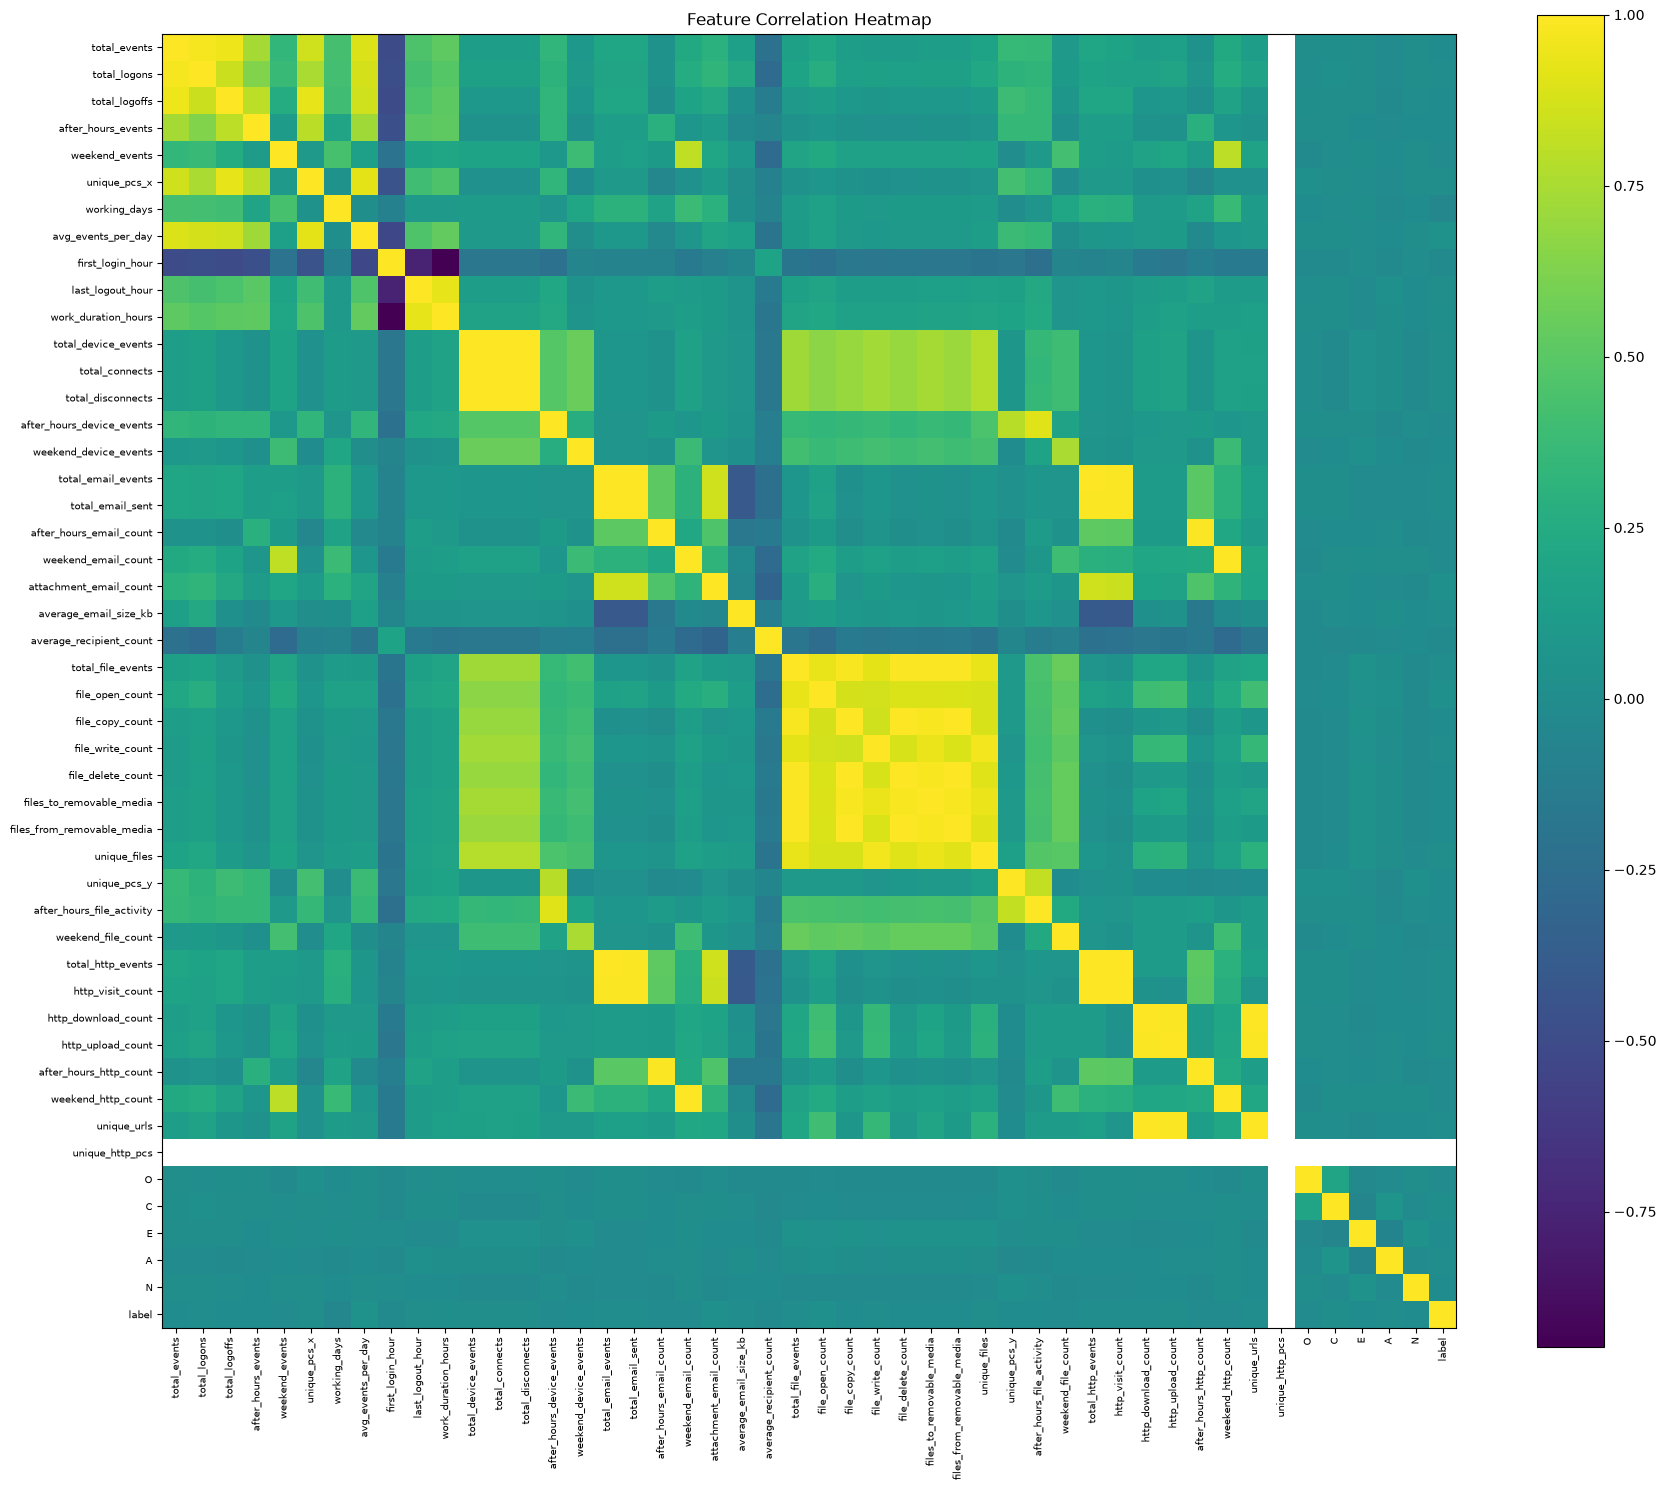

In [12]:
# Correlation Heatmap
plt.figure(figsize=(18, 15))

plt.imshow(correlation_matrix)

plt.colorbar()

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=90,
    fontsize=7
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    fontsize=7
)

plt.title("Feature Correlation Heatmap")

plt.tight_layout()

plt.show()

In [13]:
# Correlation with Target Variable
target_corr = (
    correlation_matrix["label"]
    .sort_values(ascending=False)
)

print(target_corr)

label                         1.000000
avg_events_per_day            0.045365
file_open_count               0.028981
attachment_email_count        0.026686
C                             0.019616
work_duration_hours           0.019146
unique_pcs_x                  0.015089
last_logout_hour              0.014594
http_upload_count             0.011864
unique_files                  0.011520
total_connects                0.011106
total_device_events           0.011096
total_disconnects             0.011086
file_write_count              0.010409
average_email_size_kb         0.010310
A                             0.008723
total_http_events             0.007805
total_email_sent              0.007672
total_file_events             0.007562
http_download_count           0.007557
http_visit_count              0.007173
total_email_events            0.007168
total_logons                  0.006772
unique_urls                   0.005936
total_events                  0.002721
files_from_removable_medi

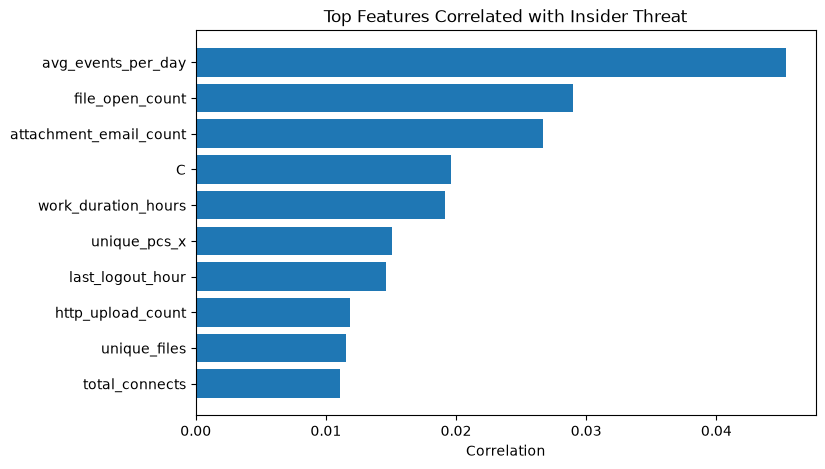

In [14]:
# Top 10 Features Correlated with Insider Threat
top_features = target_corr.drop("label").head(10)

plt.figure(figsize=(8, 5))

plt.barh(top_features.index, top_features.values)

plt.title("Top Features Correlated with Insider Threat")

plt.xlabel("Correlation")

plt.gca().invert_yaxis()

plt.show()

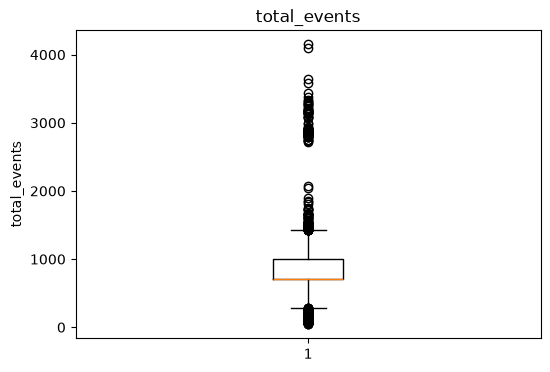

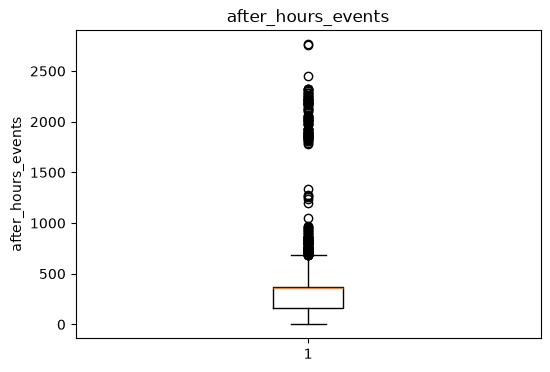

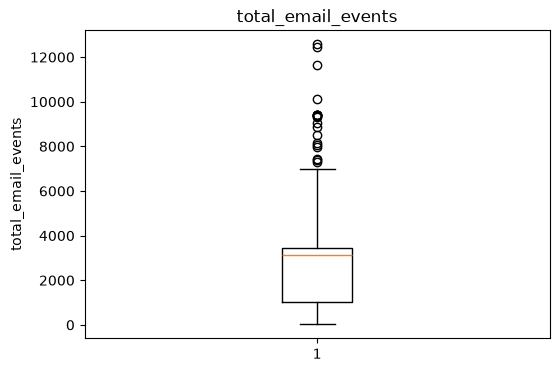

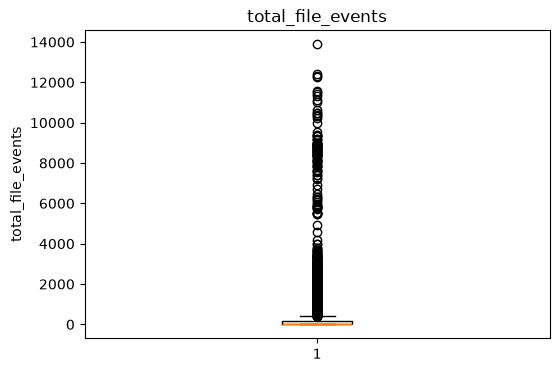

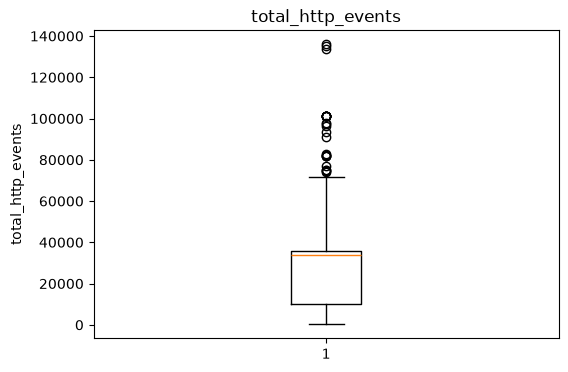

In [15]:
# Detect Outliers Using Boxplots
important_features = [
    "total_events",
    "after_hours_events",
    "total_email_events",
    "total_file_events",
    "total_http_events"
]

for feature in important_features:

    plt.figure(figsize=(6, 4))

    plt.boxplot(df[feature])

    plt.title(feature)

    plt.ylabel(feature)

    plt.show()